In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon

def configurar_mapa(ax):
    A=(0,0)
    D=(10,5)
    ax.set_aspect('equal')
    ax.set_xlim(-4, 12)
    ax.set_ylim(-2, 8)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    ax.set_xlabel('Coordenada X', fontsize=11, fontweight='bold')
    ax.set_ylabel('Coordenada Y', fontsize=11, fontweight='bold')

    # Marcar coordenadas
    ax.set_xticks(np.arange(-4, 12, 1))
    ax.set_yticks(np.arange(-2, 8, 1))
    
    # Puntos A y D
    ax.plot(A[0], A[1], 'go', markersize=12, label='Inicio (Casa de Roberto)', zorder=5)
    ax.plot(D[0], D[1], 'ro', markersize=12, label='Destino (Casa de Damián)', zorder=5)
    ax.text(A[0]+0.1, A[1]-0.3, 'A (0,0)', fontsize=11, fontweight='bold', color='green')
    ax.text(D[0]+0.1, D[1]+0.2, 'D (10,5)', fontsize=11, fontweight='bold', color='red')
    
    return ax
    
def configurar_obstaculos(ax):
    commons = dict(edgecolor='black', alpha=0.7, linewidth=2)
    
    pozo_vertices = np.array([(1.5, 5.5), (2.2, 5.8), (2.8, 5.5), (2.5, 4.8), (1.8, 4.8)])
    pozo = Polygon(pozo_vertices, facecolor='darkblue', **commons)
    roca = Circle((4, 3), 1.2, facecolor='gray', **commons)
    casa = Rectangle((6, 1), 2, 3, facecolor='brown', **commons)
    
    arbustos_vertices = np.array([(8.5, 6.2), (9.5, 6.0), (9.2, 5.3), (8.2, 5.5)])
    arbustos = Polygon(arbustos_vertices,
                       facecolor='green',
                       edgecolor='darkgreen',
                       alpha=0.5,
                       linestyle='--',
                       linewidth=2)
    
    ax.add_patch(pozo)
    ax.add_patch(roca)
    ax.add_patch(casa)
    ax.add_patch(arbustos)
    
    text_props = dict(ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(4, 3, 'Roca', **text_props)
    ax.text(7, 2.5, 'Casa\nAbandonada', **text_props)
    ax.text(2.15, 5.3, 'Pozo', **text_props)
    ax.text(8.85, 5.75, 'Arbustos', **text_props)
    
    obstaculos = [
        {'nombre': 'Roca', 'poligono': roca},
        {'nombre': 'Casa', 'poligono': casa},
        {'nombre': 'Pozo', 'poligono': pozo},
        {'nombre': 'Arbustos', 'poligono': arbustos},
    ]
    return ax, obstaculos 




def bezier_cubica(t, P0, P1, P2, P3):
    return ((1 - t)**3) * P0 \
           + 3 * ((1 - t)**2) * t * P1 \
           + 3 * (1 - t) * (t**2) * P2 \
           + (t**3) * P3


def graficar_bezier_cubica(ax, P1, P2, n=1000):
    P0 = np.array([0, 0])
    P3 = np.array([10, 5])
    
    P1 = np.array(P1)
    P2 = np.array(P2)
    
    t_vals = np.linspace(0, 1, n)
    curva = np.array([bezier_cubica(t, P0, P1, P2, P3) for t in t_vals])
    
    diferencias = np.diff(curva, axis=0)
    distancias = np.linalg.norm(diferencias, axis=1)
    longitud = np.sum(distancias)
    
    ax.plot(curva[:,0], curva[:,1], 
            color='purple', 
            linewidth=3, 
            label=f'Curva Bézier cúbica\nLongitud ≈ {longitud:.2f}',
            zorder=4)
    
    control = np.array([P0, P1, P2, P3])
    ax.plot(control[:,0], control[:,1], 
            'k--', alpha=0.6,
            label='Polígono de control')
    
    ax.scatter(control[:,0], control[:,1], 
               color='black', 
               s=80, 
               zorder=5)
    
    ax.text(P1[0], P1[1]+0.3, 'P1', fontweight='bold')
    ax.text(P2[0], P2[1]+0.3, 'P2', fontweight='bold')
    
    return ax, longitud

Longitud aproximada de la curva: 11.7134


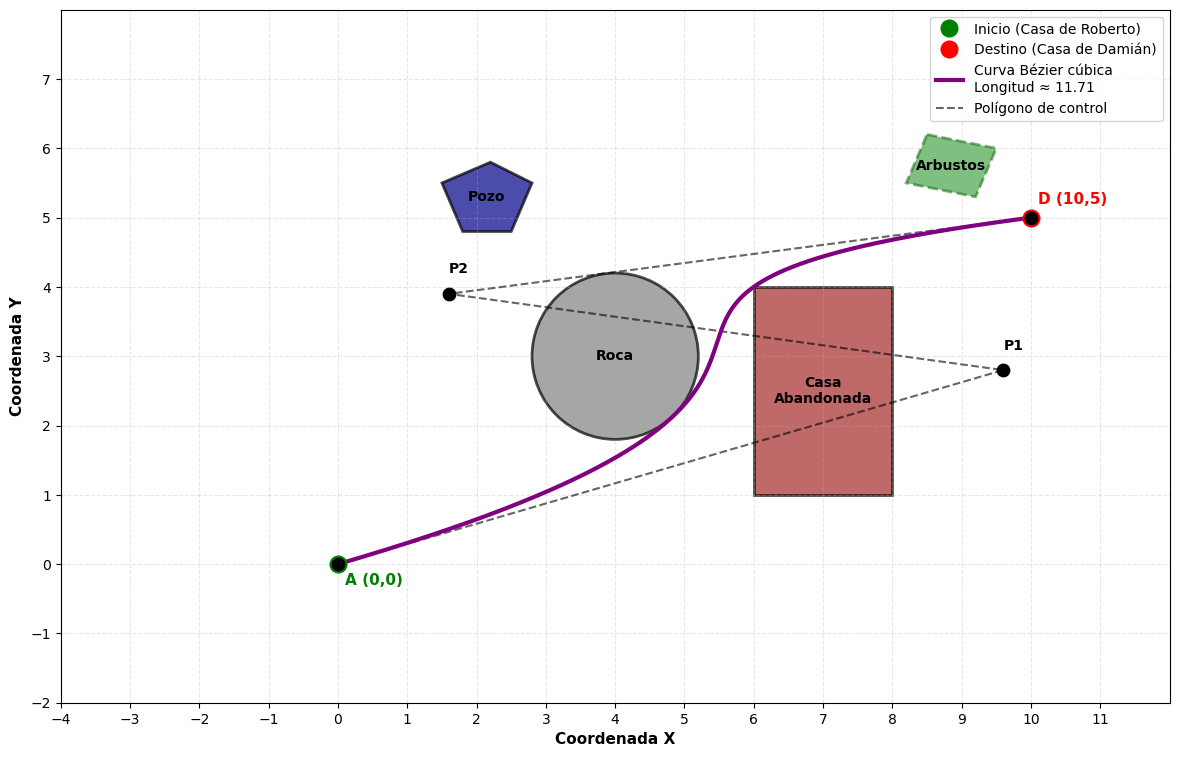

In [3]:
fig, ax = plt.subplots(figsize=(15,9)) 
ax = configurar_mapa(ax)
ax, obstaculos = configurar_obstaculos(ax)

P1 = (9.6, 2.8)
P2 = (1.6, 3.9)

ax, L = graficar_bezier_cubica(ax, P1, P2)

print(f"Longitud aproximada de la curva: {L:.4f}")

ax.legend()
plt.show()